In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import seaborn as sns

sns.set_theme()

# Exercício: Seleção de Variáveis com Pipeline e Forward Selection

Use o dataset `diabetes` do `sklearn.datasets` para avaliar como o desempenho de uma regressão linear varia com diferentes números de variáveis.

## Instruções

1. Carregue o dataset usando `load_diabetes()`. ✅

2. Divida os dados em treino (60%), validação (20%) e teste (20%) usando `train_test_split()`. ✅

3. Para cada quantidade de variáveis de 1 até o total de variáveis: 
   - Crie um `Pipeline` contendo dois passos:
     - Seleção de variáveis com `SequentialFeatureSelector()` usando:
       - `estimator=LinearRegression()`
       - `direction='forward'`
       - `cv=5`
       - `n_features_to_select=k` (o número atual de variáveis no loop)
     - Um modelo `LinearRegression()`.
   - Ajuste o pipeline na base de treino.
   - Calcule o MSE na base de validação.
   - Registre:
     - O número de variáveis usadas (`k`).
     - O MSE na validação.
     - A lista de variáveis selecionadas.

4. Organize os resultados em uma tabela.

5. Faça um gráfico do MSE em função do número de variáveis.

## Esboço da função para criar o pipeline

```python
def criar_pipeline(n_variaveis):
    """
    Cria um pipeline com seleção de variáveis via forward selection
    e regressão linear.

    Parâmetros:
    - n_variaveis: número de variáveis a serem selecionadas.

    Retorna:
    - Pipeline sklearn com seleção de variáveis e regressão linear.
    """
    pipe = Pipeline([
        ('selecao', SequentialFeatureSelector(
            estimator=LinearRegression(),
            n_features_to_select=n_variaveis,
            direction='forward',
            cv=5
        )),
        ('regressor', LinearRegression())
    ])
    return pipe


In [2]:
def criar_pipeline(n_variaveis):
    """
    Cria um pipeline com seleção de variáveis via forward selection
    e regressão linear.

    Parâmetros:
    - n_variaveis: número de variáveis a serem selecionadas.

    Retorna:
    - Pipeline sklearn com seleção de variáveis e regressão linear.
    """
    pipe = Pipeline([
        ('selecao', SequentialFeatureSelector(
            estimator=LinearRegression(),
            n_features_to_select=n_variaveis,
            direction='forward',
            cv=5
        )),
        ('regressor', LinearRegression())
    ])
    return pipe

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)
X_test, X_validacao, y_test, y_validacao = train_test_split(X_test, y_test, test_size=0.5)

<Axes: xlabel='n_features'>

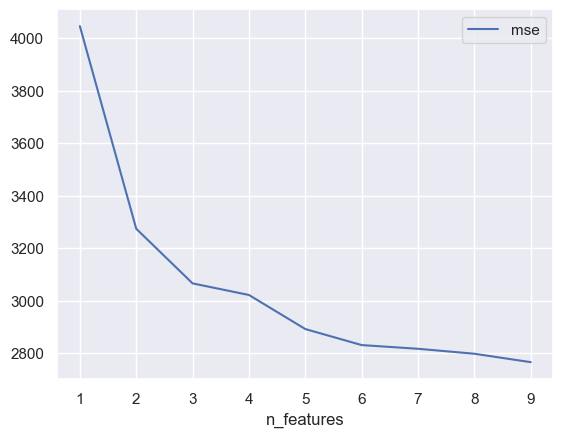

In [3]:
results = []

for i in range(1,10):
    pipe = criar_pipeline(n_variaveis=i)

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_validacao)

    mse = mean_squared_error(y_validacao, pred)

    results.append((i,mse))

pd.DataFrame(results,columns=['n_features', 'mse']).plot(kind='line', x='n_features', y='mse')

# Exercício: Regularização com Ridge e Lasso

O objetivo deste exercício é analisar como a regularização afeta os coeficientes de uma regressão linear, utilizando os modelos **Ridge** e **Lasso**.

## Objetivos

- Observar como os coeficientes variam conforme o parâmetro de regularização (`alpha`) aumenta.
- Comparar o efeito da regularização nos modelos Ridge e Lasso.

## Instruções

1. Carregue o dataset `diabetes` com a função `load_diabetes` da biblioteca `sklearn.datasets`.

2. Divida os dados em treino (60%), validação (20%) e teste (20%) utilizando duas vezes a função `train_test_split` da biblioteca `sklearn.model_selection`.

3. Crie uma sequência de valores de `alpha` usando `np.logspace(-4, 2, 100)`, que gera 100 valores entre `10^-4` e `10^2` em escala logarítmica.

4. Para cada valor de `alpha`, ajuste dois modelos utilizando a base de **treino**:
- Um modelo **Ridge** com `Ridge(alpha=...)`.
- Um modelo **Lasso** com `Lasso(alpha=..., max_iter=10000)`.

5. Guarde os coeficientes de cada modelo para cada valor de `alpha`.

6. Faça dois gráficos:
- Um gráfico dos coeficientes do **Ridge** em função de `alpha`.
- Um gráfico dos coeficientes do **Lasso** em função de `alpha`.

O eixo x deve estar em escala logarítmica (`plt.xscale('log')`) e o eixo y representa os coeficientes.

## Pergunta

O que acontece com os coeficientes à medida que o parâmetro `alpha` aumenta? Compare os comportamentos do Ridge e do Lasso.


In [12]:
results = []
features = data.feature_names

results = []
for i in np.logspace(-4,1,100):
    model = Ridge(alpha=i)

    model.fit(X_train, y_train)
    results = results + list(zip([i]*len(features), features, model.coef_))

ridge_df = pd.DataFrame(results, columns=['alpha', 'feature', 'coef'])

<Axes: xlabel='alpha', ylabel='coef'>

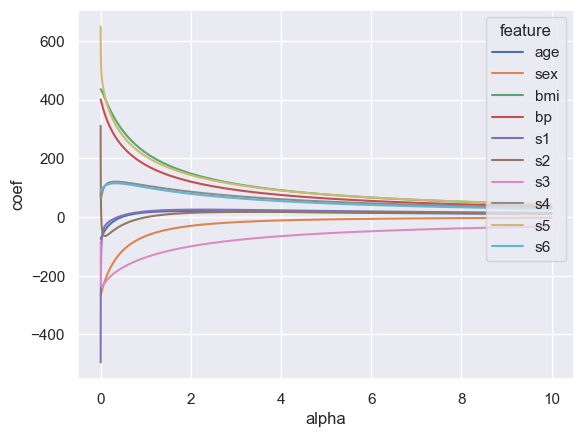

In [13]:
sns.lineplot(ridge_df, x='alpha', y='coef', hue='feature')

In [14]:
results = []
features = data.feature_names

results = []
for i in np.logspace(-4,1,100):
    model = Lasso(alpha=i)

    model.fit(X_train, y_train)
    results = results + list(zip([i]*len(features), features, model.coef_))

lasso_df = pd.DataFrame(results, columns=['alpha', 'feature', 'coef'])

<Axes: xlabel='alpha', ylabel='coef'>

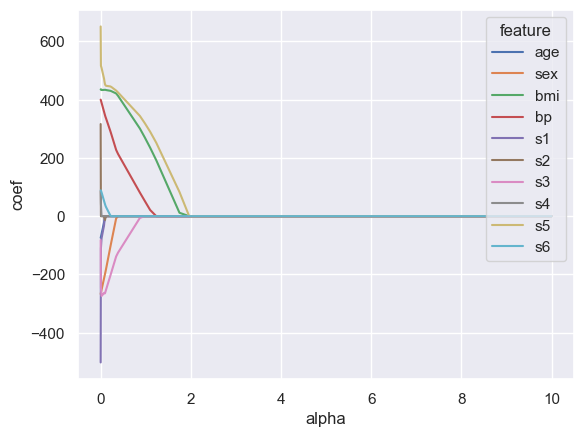

In [15]:
sns.lineplot(lasso_df, x='alpha', y='coef', hue='feature')